In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [171]:
ass_data=pd.read_csv("assessments.csv")
cor_data=pd.read_csv("courses.csv")

In [172]:
ass_data.head()

,assessment_id,month,course_id,batch,score,attendance_pct
0,1,Jan,C1,Morning,72,90
1,2,Jan,C2,Evening,45,70
2,3,Jan,C3,Morning,65,85
3,4,Jan,C4,Weekend,38,60
4,5,Feb,C1,Evening,80,95


In [173]:
cor_data.head()

,course_id,course,department
0,C1,Excel,Business
1,C2,PowerBI,Business
2,C3,SQL,Technology
3,C4,Python,Technology


In [174]:
ass_data.shape

(13, 6)

In [175]:
ass_data.duplicated().sum()

np.int64(1)

In [176]:
ass_data.drop_duplicates(inplace=True)

In [177]:
ass_data.shape

(12, 6)

In [178]:
ass_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   assessment_id   12 non-null     int64
 1   month           12 non-null     str  
 2   course_id       12 non-null     str  
 3   batch           12 non-null     str  
 4   score           12 non-null     int64
 5   attendance_pct  12 non-null     int64
dtypes: int64(3), str(3)
memory usage: 858.0 bytes


In [179]:
cor_data.shape

(4, 3)

In [180]:
cor_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   course_id   4 non-null      str  
 1   course      4 non-null      str  
 2   department  4 non-null      str  
dtypes: str(3)
memory usage: 293.0 bytes


In [181]:
merg_df=ass_data.merge(cor_data,on="course_id" , how="left")

In [182]:
merg_df

,assessment_id,month,course_id,batch,score,attendance_pct,course,department
0,1,Jan,C1,Morning,72,90,Excel,Business
1,2,Jan,C2,Evening,45,70,PowerBI,Business
2,3,Jan,C3,Morning,65,85,SQL,Technology
3,4,Jan,C4,Weekend,38,60,Python,Technology
4,5,Feb,C1,Evening,80,95,Excel,Business
5,6,Feb,C2,Weekend,55,80,PowerBI,Business
6,7,Feb,C3,Morning,48,75,SQL,Technology
7,8,Feb,C4,Evening,68,88,Python,Technology
8,9,Mar,C1,Weekend,90,98,Excel,Business
9,10,Mar,C2,Morning,60,82,PowerBI,Business


In [183]:
merg_df.shape

(12, 8)

In [184]:
merg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   assessment_id   12 non-null     int64
 1   month           12 non-null     str  
 2   course_id       12 non-null     str  
 3   batch           12 non-null     str  
 4   score           12 non-null     int64
 5   attendance_pct  12 non-null     int64
 6   course          12 non-null     str  
 7   department      12 non-null     str  
dtypes: int64(3), str(5)
memory usage: 1.2 KB


In [185]:
merg_df["pass_flag"]=(merg_df["score"]>=50)

In [186]:
merg_df["pass_flag"]=merg_df["pass_flag"].astype(int)

In [187]:
merg_df

,assessment_id,month,course_id,batch,score,attendance_pct,course,department,pass_flag
0,1,Jan,C1,Morning,72,90,Excel,Business,1
1,2,Jan,C2,Evening,45,70,PowerBI,Business,0
2,3,Jan,C3,Morning,65,85,SQL,Technology,1
3,4,Jan,C4,Weekend,38,60,Python,Technology,0
4,5,Feb,C1,Evening,80,95,Excel,Business,1
5,6,Feb,C2,Weekend,55,80,PowerBI,Business,1
6,7,Feb,C3,Morning,48,75,SQL,Technology,0
7,8,Feb,C4,Evening,68,88,Python,Technology,1
8,9,Mar,C1,Weekend,90,98,Excel,Business,1
9,10,Mar,C2,Morning,60,82,PowerBI,Business,1


In [188]:
summery_data=merg_df.groupby("department").agg(count_assessments=("assessment_id","count"),sum_pass_flag=("pass_flag","sum"))

In [189]:
merg_df.to_csv("clean_data.csv",index=False)

In [190]:
summery_data

,count_assessments,sum_pass_flag
department,,
Business,6,5
Technology,6,3


In [191]:
pass_rate=summery_data["sum_pass_flag"]/summery_data["count_assessments"]
pass_rate=pass_rate*100

In [192]:
pass_rate

department
Business      83.333333
Technology    50.000000
dtype: float64

In [193]:
summery_data_2=merg_df.groupby("course").agg(count_assessments=("assessment_id","count"),sum_pass_flag=("pass_flag","sum"))

In [194]:
summery_data_2

,count_assessments,sum_pass_flag
course,,
Excel,3,3
PowerBI,3,2
Python,3,1
SQL,3,2


In [195]:
summery_data_2.to_csv("summery_by_course.csv",index=False)
summery_data.to_csv("summery_by_depertment.csv",index=False)

In [196]:
pass_rate_by_course=summery_data_2["sum_pass_flag"]/summery_data_2["count_assessments"]
pass_rate_by_course=pass_rate_by_course*100

In [197]:
pass_rate_by_course

course
Excel      100.000000
PowerBI     66.666667
Python      33.333333
SQL         66.666667
dtype: float64

the lowest passing rate is of python 


In [198]:
x=merg_df.groupby("month",as_index=False)["score"].mean().sort_values(by="score", ascending=True)
x

,month,score
1,Jan,55.00
0,Feb,62.75
2,Mar,66.75


C:\Users\Admin\AppData\Local\Temp\ipykernel_14440\1613824440.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=x,x="month",y="score",palette="icefire")


Text(0, 0.5, 'average_score')

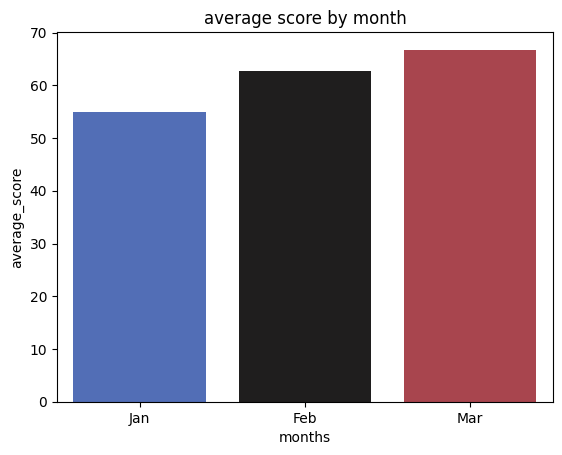

In [199]:
sns.barplot(data=x,x="month",y="score",palette="icefire")
plt.title("average score by month")
plt.xlabel("months")
plt.ylabel("average_score")